In [1]:
pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import numpy as np
import json
import pymc as pm
from solar_models import build_dynamic_model
import matplotlib.pyplot as plt
import arviz as az
import pytensor

# Disable C++ compilation to stop macOS warning spam. 
pytensor.config.cxx = ""

import warnings
warnings.filterwarnings("ignore")
print(f"NumPy version: {np.__version__}")
print("PyMC imported successfully!")

NumPy version: 1.26.4
PyMC imported successfully!


In [4]:
# Load the fully merged and engineered dataset
df = pd.read_csv('../data/merged/merged_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# Generate 3 pairs of Fourier harmonics for annual seasonality
for k in range(1, 4):
    df[f'sin_k{k}'] = np.sin(2 * np.pi * k * df['day_of_year'] / 365.25)
    df[f'cos_k{k}'] = np.cos(2 * np.pi * k * df['day_of_year'] / 365.25)

# Store standardizations for back-calculation later
demand_mean, demand_std = df['demand_mwh_day'].mean(), df['demand_mwh_day'].std()

# Standardize features (Z-scores)
df['demand_scaled'] = (df['demand_mwh_day'] - demand_mean) / demand_std
df['temp_scaled'] = (df['temp_mean_c'] - df['temp_mean_c'].mean()) / df['temp_mean_c'].std()
df['proxy_scaled'] = (df['selfcons_theoretical_mwh'] - df['selfcons_theoretical_mwh'].mean()) / df['selfcons_theoretical_mwh'].std()

# Piecewise (Heating and Cooling Degrees)
# Assuming temp_celsius is your raw, unscaled temperature column
df['heating_degrees'] = np.maximum(18 - df['temp_mean_c'], 0)
df['cooling_degrees'] = np.maximum(df['temp_mean_c'] - 22, 0)
df['heating_scaled'] = (df['heating_degrees'] - df['heating_degrees'].mean()) / df['heating_degrees'].std()
df['cooling_scaled'] = (df['cooling_degrees'] - df['cooling_degrees'].mean()) / df['cooling_degrees'].std()

# Autoregressive (Lag 7)
# Shift the scaled demand down by 7 days. 
# Use bfill() to fill the first 7 days so PyMC doesn't crash on NaNs.
df['demand_lag_7_scaled'] = df['demand_scaled'].shift(7).bfill()

# Temperature-Humidity Index (THI)
# Assuming you have a raw 'humidity' column (percentage 0-100)
df['thi'] = df['temp_mean_c'] - 0.55 * (1 - (df['humidity_mean_pct'] / 100)) * (df['temp_mean_c'] - 14.5)
df['thi_scaled'] = (df['thi'] - df['thi'].mean()) / df['thi'].std()


In [5]:
# 1. Load the configuration file and the data
with open('experiments_config.json', 'r') as file:
    experiments = json.load(file)

os.makedirs('models', exist_ok=True)
results_dict = {}

In [6]:
# 2. Execute the Pipeline
for config in experiments:
    model_name = config["name"]
    file_path = f"models/trace_{model_name}.nc"
    
    print(f"\n--- Processing: {model_name} ---")
    
    if os.path.exists(file_path):
        print(f"Loading existing trace from {file_path}...")
        trace = az.from_netcdf(file_path)
    else:
        print(f"Building model and running MCMC for {model_name}...")
        
        # Build the model using the imported blueprint and current JSON config
        model = build_dynamic_model(df, config)
        
        with model:
            trace = pm.sample(draws=1000, 
                              tune=1000, 
                              chains=4, 
                              target_accept=0.95, 
                              nuts_sampler="numpyro", 
                              return_inferencedata=True,
                              random_seed=42)
            
            print(f"Saving to {file_path}...")
            az.to_netcdf(trace, file_path)
    
    results_dict[model_name] = trace

print("\nPipeline execution complete!")


--- Processing: v1_baseline ---
Loading existing trace from models/trace_v1_baseline.nc...

--- Processing: v2_strict_solar ---
Loading existing trace from models/trace_v2_strict_solar.nc...

--- Processing: v3_normal_likelihood ---
Loading existing trace from models/trace_v3_normal_likelihood.nc...

--- Processing: v4_lognormal_solar ---
Building model and running MCMC for v4_lognormal_solar...


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:01<?, ?it/s]


Running chain 0:   5%|▌         | 100/2000 [00:01<00:05, 364.27it/s]



Running chain 0:  10%|█         | 200/2000 [00:02<00:06, 287.84it/s]


Running chain 0:  15%|█▌        | 300/2000 [00:02<00:05, 327.70it/s]


Running chain 0:  20%|██        | 400/2000 [00:02<00:04, 367.44it/s]


Running chain 0:  25%|██▌       | 500/2000 [00:02<00:03, 404.19it/s]


Running chain 0:  30%|███       | 600/2000 [00:03<00:03, 423.55it/s]


Running chain 0:  35%|███▌      | 700/2000 [00:03<00:02, 442.37it/s]




Running chain 0:  40%|████      | 800/2000 [00:03<00:02, 466.00it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:03<00:02, 484.39it/s]


Running chain 0:  50%|█████     | 1000/2000 [00:03<00:02, 486.69it/s]


Running chain 0:  55%|█████▌    | 1100/2000 [00:04<00:01, 497.05it/s]


Running chain 0:  60%|██████    | 1200/2000 [00:04<00:01, 505.14it/s]


Running chain 0:  65%|

Saving to models/trace_v4_lognormal_solar.nc...

--- Processing: v5_heavy_tail_solar ---
Building model and running MCMC for v5_heavy_tail_solar...


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:01<?, ?it/s]


Running chain 0:   5%|▌         | 100/2000 [00:01<00:05, 319.91it/s]




Running chain 0:  10%|█         | 200/2000 [00:02<00:06, 278.43it/s]


Running chain 0:  15%|█▌        | 300/2000 [00:02<00:05, 330.27it/s]


Running chain 0:  20%|██        | 400/2000 [00:02<00:04, 390.76it/s]



Running chain 0:  25%|██▌       | 500/2000 [00:02<00:03, 421.73it/s]


Running chain 0:  30%|███       | 600/2000 [00:02<00:03, 433.22it/s]


Running chain 0:  35%|███▌      | 700/2000 [00:03<00:02, 448.15it/s]


Running chain 0:  40%|████      | 800/2000 [00:03<00:02, 470.87it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:03<00:02, 490.29it/s]


Running chain 0:  50%|█████     | 1000/2000 [00:03<00:02, 490.61it/s]


Running chain 0:  55%|█████▌    | 1100/2000 [00:03<00:01, 502.72it/s]

Running chain 0:  60%|██████    | 1200/2000 [00:04<00:01, 509.52it/s]


Running chain 0:  65%|█

Saving to models/trace_v5_heavy_tail_solar.nc...

--- Processing: v6_wide_uninformed ---
Building model and running MCMC for v6_wide_uninformed...


...

Saving to models/trace_v7_piecewise_academic.nc...

--- Processing: v8_autoregressive_academic ---
Building model and running MCMC for v8_autoregressive_academic...


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:01<?, ?it/s]


Running chain 0:   5%|▌         | 100/2000 [00:01<00:05, 317.24it/s]


Running chain 0:  10%|█         | 200/2000 [00:02<00:06, 257.65it/s]


Running chain 0:  15%|█▌        | 300/2000 [00:02<00:05, 287.01it/s]


Running chain 0:  20%|██        | 400/2000 [00:02<00:04, 329.93it/s]


Running chain 0:  25%|██▌       | 500/2000 [00:02<00:04, 352.40it/s]


Running chain 0:  30%|███       | 600/2000 [00:03<00:03, 359.61it/s]



Running chain 0:  35%|███▌      | 700/2000 [00:03<00:03, 328.71it/s]




Running chain 0:  40%|████      | 800/2000 [00:03<00:03, 306.88it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:04<00:03, 318.04it/s]


Running chain 0:  50%|█████     | 1000/2000 [00:04<00:03, 312.72it/s]


Running chain 0:  55%|█████▌    | 1100/2000 [00:04<00:02, 315.10it/s]


Running chain 0:  60%|██████    | 1200/2000 [00:05<00:02, 329.84it/s]


Running chain 0:  65%|

Saving to models/trace_v8_autoregressive_academic.nc...

--- Processing: v9_thi_academic ---
Building model and running MCMC for v9_thi_academic...


Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:01<?, ?it/s]




Running chain 0:   5%|▌         | 100/2000 [00:01<00:04, 433.73it/s]


Running chain 0:  10%|█         | 200/2000 [00:01<00:05, 345.98it/s]


Running chain 0:  20%|██        | 400/2000 [00:02<00:03, 427.22it/s]





Running chain 0:  25%|██▌       | 500/2000 [00:02<00:03, 434.42it/s]


Running chain 0:  30%|███       | 600/2000 [00:02<00:03, 444.89it/s]


Running chain 0:  35%|███▌      | 700/2000 [00:02<00:02, 449.67it/s]


Running chain 0:  40%|████      | 800/2000 [00:02<00:02, 468.12it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:03<00:02, 476.22it/s]


Running chain 0:  50%|█████     | 1000/2000 [00:03<00:02, 476.38it/s]


Running chain 0:  60%|██████    | 1200/2000 [00:03<00:01, 485.59it/s]


Running chain 0:  65%|██████▌   | 1300/2000 [00:03<00:01, 494.49it/s]


Running chain 0:  70%|███████   | 1400/2000 [00:04<00:01, 487.45it/s]



Running chain 0:  

Saving to models/trace_v9_thi_academic.nc...

Pipeline execution complete!


In [7]:
print("Retroactively computing missing log-likelihoods...")

# Loop through your configurations to calculate the missing data
for config in experiments:
    model_name = config["name"]
    trace = results_dict[model_name]
    
    # Check if the log_likelihood group is missing
    if "log_likelihood" not in trace:
        print(f"Computing for {model_name}...")
        
        # 1. Rebuild the specific model blueprint
        model = build_dynamic_model(df, config)
        
        # 2. Tell PyMC to calculate the pointwise log-likelihood
        with model:
            pm.compute_log_likelihood(trace)
            
        # 3. The Unix File Swap (Bypassing the lock)
        file_path = f"models/trace_{model_name}.nc"
        temp_path = f"models/temp_{model_name}.nc"
        
        print(f"   -> Saving safely to bypass file lock...")
        # Save to a brand new temporary file
        trace.to_netcdf(temp_path)
        
        # Atomically replace the old locked file with the new complete one
        os.replace(temp_path, file_path)

print("\nAll log-likelihoods successfully computed! You are ready to run the comparison.")

Retroactively computing missing log-likelihoods...
Computing for v1_baseline...


   -> Saving safely to bypass file lock...
Computing for v4_lognormal_solar...


   -> Saving safely to bypass file lock...
Computing for v5_heavy_tail_solar...


   -> Saving safely to bypass file lock...
Computing for v6_wide_uninformed...


   -> Saving safely to bypass file lock...
Computing for v7_piecewise_academic...


   -> Saving safely to bypass file lock...
Computing for v8_autoregressive_academic...


   -> Saving safely to bypass file lock...
Computing for v9_thi_academic...


   -> Saving safely to bypass file lock...

All log-likelihoods successfully computed! You are ready to run the comparison.


Calculating Leave-One-Out Cross-Validation (LOO) for all models...

--- BAYESIAN MODEL LEADERBOARD ---


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
v8_autoregressive_academic,0,3995.386380,15.627189,0.000000,8.853376e-01,150.900750,0.000000,False,deviance
v9_thi_academic,1,6332.076356,14.055503,2336.689976,9.010517e-02,127.828068,115.101577,False,deviance
v1_baseline,2,6336.642050,13.668138,2341.255670,1.177541e-14,127.333152,114.447060,False,deviance
v2_strict_solar,3,6336.764093,13.723073,2341.377712,2.737698e-14,127.315544,114.433178,False,deviance
v6_wide_uninformed,4,6337.064580,13.869692,2341.678199,3.099395e-14,127.262148,114.412836,False,deviance
v5_heavy_tail_solar,5,6337.103261,13.909156,2341.716880,2.663638e-14,127.286470,114.421116,False,deviance
v4_lognormal_solar,6,6337.191417,13.948568,2341.805036,3.389087e-14,127.285092,114.423410,False,deviance
v7_piecewise_academic,7,6443.516605,13.893250,2448.130224,0.000000e+00,123.961851,116.093825,False,deviance
v3_normal_likelihood,8,6807.232373,13.068935,2811.845993,2.455722e-02,143.111109,128.660449,False,deviance


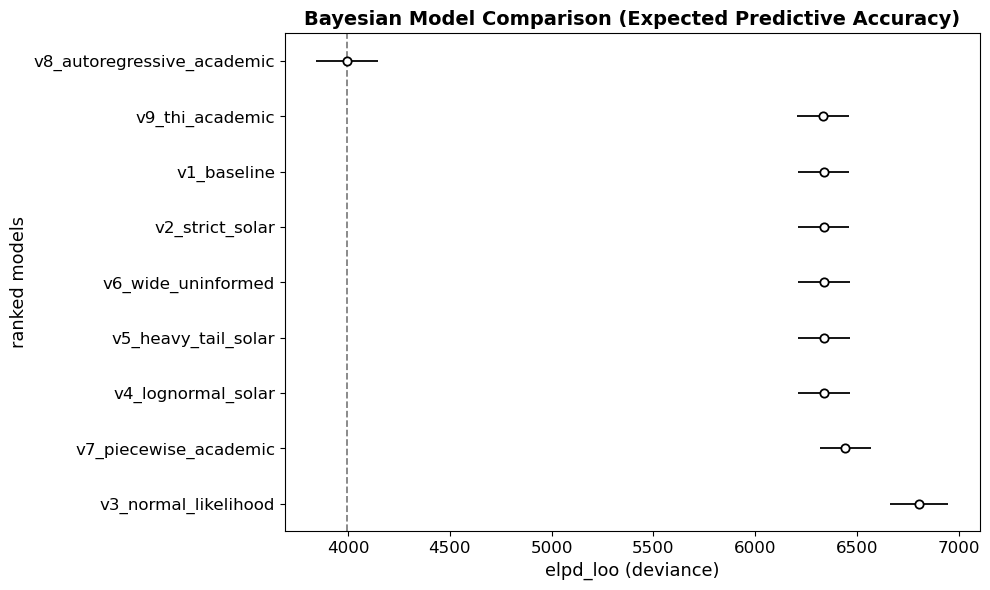

In [8]:
# 1. Compare the models using Leave-One-Out (LOO) cross-validation
print("Calculating Leave-One-Out Cross-Validation (LOO) for all models...")
comparison_df = az.compare(results_dict, ic="loo", scale="deviance")

# 2. Display the mathematical leaderboard
print("\n--- BAYESIAN MODEL LEADERBOARD ---")
display(comparison_df)

# 3. Visualize the comparison
fig, ax = plt.subplots(figsize=(10, 6))
az.plot_compare(comparison_df, ax=ax, textsize=12)
ax.set_title("Bayesian Model Comparison (Expected Predictive Accuracy)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()